In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(np.__version__)
print(pd.__version__)


1.26.4
3.0.3


## CSV 表格的含义
按Esc在按M就变成Markdwon的文本了
例如第一行
| event | layer | phi    | tbin | adc |
| ----- | ----- | ------ | ---- | --- |
| 74    | 3     | -0.399 | -8   | 210 |
在 Event 74
第3层探测器
位置
phi = -0.399
time bin = -8
ADC = 210
event：老师已经帮你筛选好了，目前只看event74
layer：探测器有很多层。
phi 是：方位角
phi表示：围绕圆柱转了多少角度，单位是radian（-π ~ +π）
time bin可以理解为：时间坐标，tbin = 40说明信号在第40个时间格被记录
index="tbin"
columns="phi"
实际上就是建立：
       phi →
tbin
二维图像
ADC：Analog to Digital Converter
简单理解：信号强度

zelem表示：沿z方向的探测器单元编号（可以先忽略）

x y z 真实空间坐标：

plot_x plot_y plot_z这是老师预先计算好的：用于画图的坐标通常和：
tbin
phi
z有关。

In [5]:
# 读取CSV里面的数据
CSV_FILE = "event74_hits.csv"

df = pd.read_csv(CSV_FILE)

print(df.shape)
df.head()

(431640, 12)


,event,layer,phi,tbin,adc,zelem,x,y,z,plot_x,plot_y,plot_z
0,74,3,-0.399423,-8.0,210,0,7.09161,-2.99346,-7.77245,-8.0,2.76386,-1.16666
1,74,3,0.806673,40.0,45,0,5.04564,5.26504,-9.37245,40.0,2.07571,2.16597
2,74,3,0.807742,40.0,45,0,5.04013,5.27055,-9.37245,40.0,2.07340,2.16819
3,74,3,0.649190,82.0,120,0,5.86202,4.44885,-4.57245,82.0,2.38972,1.81362
4,74,3,0.649190,82.0,90,0,5.86202,4.44885,-2.97245,82.0,2.38972,1.81362


In [6]:
# 查看数据结构
print("Columns:")
print(df.columns)

print("\nEvents:")
print(df["event"].unique())

print("\nLayers:")
print(sorted(df["layer"].unique()))

Columns:
Index(['event', 'layer', 'phi', 'tbin', 'adc', 'zelem', 'x', 'y', 'z',
       'plot_x', 'plot_y', 'plot_z'],
      dtype='str')

Events:
[74]

Layers:
[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56]


In [7]:
#查看各层Hit的数量
layer_counts = (
    df.groupby("layer")
      .size()
      .sort_index()
)

print(layer_counts)

layer
3       454
4       404
5       434
6       483
7      8794
8      9123
9      8728
10     9266
11     9089
12     8293
13     8997
14     7767
15     8018
16     8928
17    11460
18    11411
19    10194
20     9807
21     8782
22     8215
23     9723
24    10629
25     9516
26    10738
27     9148
28     9366
29     8653
30     9750
31     8905
32     9053
33     8013
34     8444
35     8122
36     7964
37     8564
38    10131
39    10679
40    10346
41     8793
42     9731
43     9588
44     7853
45     7523
46     7942
47     8607
48     7375
49     8258
50     8106
51     9749
52     8288
53     6974
54     6358
55       60
56       44
dtype: int64


原来的 CSV 长这样，坐标 + 数值

phi      tbin     adc

0.1       10      50
0.2       10      20
0.1       11      80
0.2       11      10

        phi

       0.1   0.2

10      50    20

11      80    10

行 = tbin
列 = phi
格子 = adc

这样就是一张图片了


In [ ]:
# 生产2D ADC的图
# 这段代码其实是在做一件非常重要的事：
# 把 CSV 里的 hit 数据，转换成一张二维图片
# 程序只看Event 74和Layer7

EVENT_ID = 74
LAYER_ID = 7

sub = df[
    (df["event"] == EVENT_ID) &
    (df["layer"] == LAYER_ID)
]

image_df = sub.pivot_table(
    index="tbin",
    columns="phi",
    values="adc",
    aggfunc="sum",
    fill_value=0
)

arr = image_df.values

tbins = image_df.index.values
phis = image_df.columns.values

print(arr.shape)

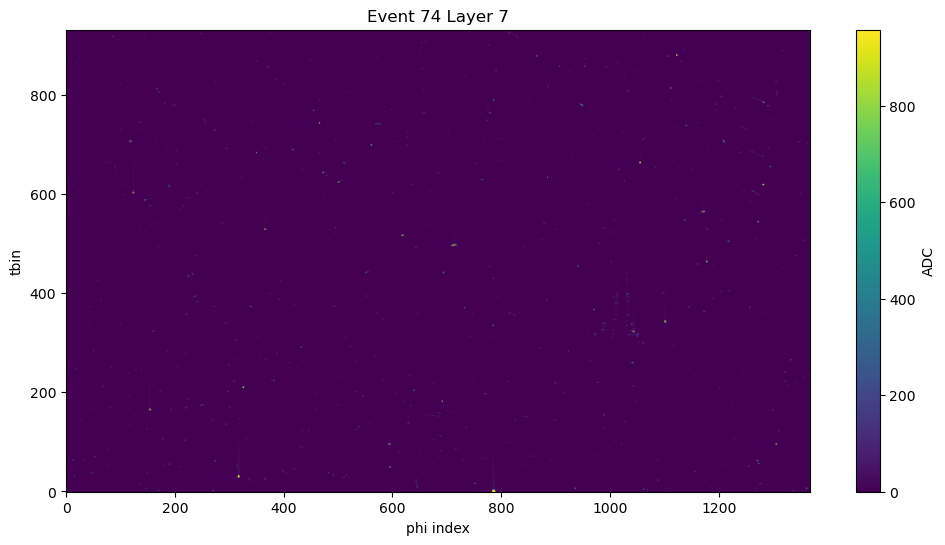

In [9]:
# 看看这一层长什么样子
plt.figure(figsize=(12,6))

plt.imshow(
    arr,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="ADC")

plt.xlabel("phi index")
plt.ylabel("tbin")

plt.title(
    f"Event {EVENT_ID} Layer {LAYER_ID}"
)

plt.show()
# 用肉眼观察：是不是有亮点
# 是不是有cluster
# 是不是有噪声

第1步：设置参数，设置Cluster为5*5 ADC要大于50,小于50的认为是噪声
第2步：存储cluster
clusters = []
以后找到一个cluster：
cluster1
cluster2
cluster3
...
全部放进去。
第3步：扫描整张ADC图
4步：取中心点
center = arr[i,j]
例如：
0 1 0
2 8 3
1 4 2
那么：center = 8
第5步：过滤小噪声
if center < MIN_ADC:
    continue

第6步：取周围邻居
neighbors = arr[i-1:i+2, j-1:j+2]
得到：
0 1 0
2 8 3
1 4 2
这就是：
3×3邻域

第7步：判断是不是局部最大值
if center == neighbors.max():
检查：
8 == 8
成立。
例如：
0 1 0
2 5 3
1 4 8
如果检查中心5：

第8步：保证唯一最大
if np.sum(neighbors == center) > 1:
    continue
避免：
2 8 8
1 8 3
0 1 2
这种情况。
因为：
有多个8

第9步：检查5×5是否越界

所以：
if (
    i-half < 0 or
    ...
):
    continue
跳过边缘点。


第10步：截取5×5区域
patch = arr[
    i-half:i+half+1,
    j-half:j+half+1
]
假设找到峰：
0 0 1 0 0
0 2 5 3 0
0 4 9 4 0
0 2 3 1 0
0 0 0 0 0
那么：
patch
就是整个：
5×5小图

第11步：保存cluster
clusters.append(...)

第12步：最后统计
print("Found clusters:", len(clusters))

In [17]:
# 寻找local Max
# 二维ADC图-》找到所有亮点-》以亮点为中心截取5×5 形成cluster
WINDOW_SIZE = 5
# ADC小于5认为是系统噪声，就忽略了
MIN_ADC = 50

half = WINDOW_SIZE // 2
clusters = []

for i in range(half, arr.shape[0] - half):
    for j in range(half, arr.shape[1] - half):

        center = arr[i, j]

        if center < MIN_ADC:
            continue

        patch = arr[
            i-half:i+half+1,
            j-half:j+half+1
        ]

        # 要求中心点是整个5x5里的唯一最大值
        if center != patch.max():
            continue

        if np.sum(patch == center) > 1:
            continue

        clusters.append(
            {
                "tbin": tbins[i],
                "phi": phis[j],
                "adc": center,
                "patch": patch
            }
        )

print("Found clusters:", len(clusters))

Found clusters: 722


为什么会形成 Cluster？

真实粒子穿过探测器时：

粒子
  ↓
释放电荷
  ↓
电荷扩散
  ↓
多个相邻像素都有信号

因此不会出现：

0 0 0
0 9 0
0 0 0

更多时候会出现：

0 1 0
2 9 3
1 4 1

所以一个粒子对应的往往是一整个 cluster。

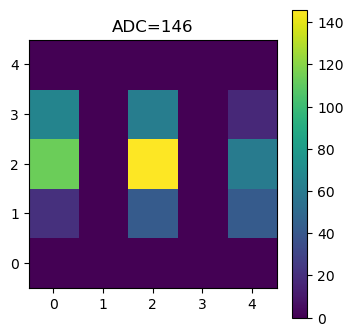

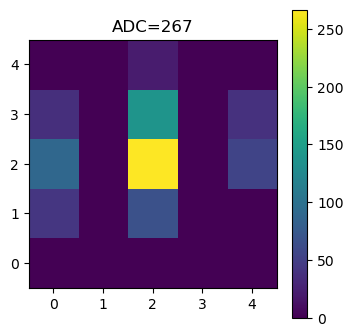

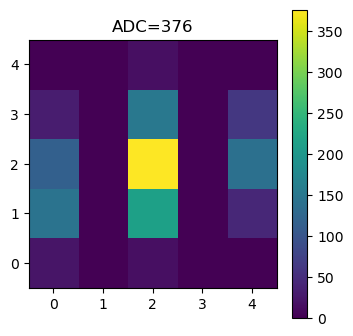

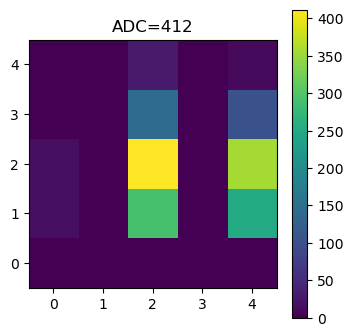

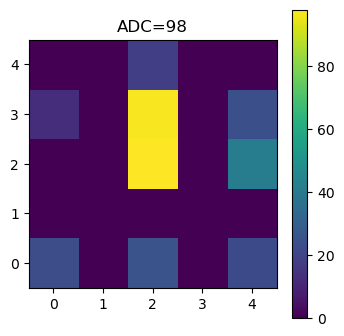

In [18]:
# 显示前面几个Cluster
for n in range(min(5, len(clusters))):

    plt.figure(figsize=(4,4))

    plt.imshow(
        clusters[n]["patch"],
        origin="lower"
    )

    plt.colorbar()

    plt.title(
        f"ADC={clusters[n]['adc']}"
    )

    plt.show()

In [12]:
# 保存数据
rows = []

for c in clusters:

    row = {
        "phi": c["phi"],
        "tbin": c["tbin"],
        "adc": c["adc"]
    }

    pixels = c["patch"].flatten()

    for k, val in enumerate(pixels):
        row[f"pixel_{k}"] = val

    rows.append(row)

clusters_df = pd.DataFrame(rows)

clusters_df.to_csv(
    "clusters_5x5.csv",
    index=False
)

print(clusters_df.shape)
clusters_df.head()

(2193, 28)


,phi,tbin,adc,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,...,pixel_15,pixel_16,pixel_17,pixel_18,pixel_19,pixel_20,pixel_21,pixel_22,pixel_23,pixel_24
0,-2.263650,2.0,143,0,0,0,0,0,0,0,...,0,0,115,0,376,0,0,30,0,150
1,0.423339,2.0,113,0,0,0,0,0,17,0,...,44,0,66,0,62,0,0,0,0,0
2,0.428646,2.0,146,0,0,0,0,0,20,0,...,66,0,62,0,17,0,0,0,0,0
3,0.433954,2.0,61,0,0,0,0,22,42,0,...,62,0,17,0,0,0,0,0,0,0
4,2.912800,2.0,89,0,0,0,0,0,0,0,...,0,0,36,0,138,0,0,0,0,20
